In [2]:
import torch
from torch import nn
from d2l import torch as d2l

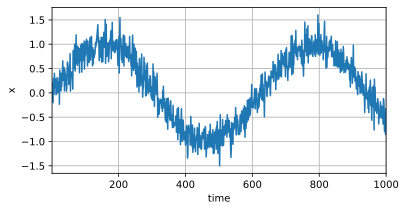

In [3]:
T=1000
time=torch.arange(1,T+1,dtype=torch.float32)
x=torch.sin(0.01*time)+torch.normal(0,0.2,(T,))
d2l.plot(time,[x],'time','x',xlim=[1,1000],figsize=(6,3))

In [4]:
x

tensor([-0.1646,  0.1294,  0.2088, -0.2018,  0.2946,  0.2743, -0.0264,  0.4019,
         0.2552,  0.1066,  0.2864,  0.2781, -0.0406,  0.0755,  0.0136,  0.3141,
        -0.0029,  0.2232,  0.0289,  0.1929,  0.0221,  0.3031, -0.2339,  0.4673,
         0.3115,  0.1995,  0.3557,  0.0429,  0.3987,  0.1364,  0.4153,  0.4033,
         0.6575,  0.3009,  0.2538,  0.3748,  0.5226,  0.0410,  0.4804,  0.4009,
         0.1589,  0.3824,  0.3287,  0.0334,  0.0934,  0.4429,  0.6349,  0.6011,
         0.5549,  0.4986,  0.1683,  0.2499,  0.4624,  0.5138,  0.8052,  0.0360,
         0.4249,  0.3402,  0.3869,  0.4292,  0.3983,  0.2633,  0.0756,  0.8688,
         0.7935,  0.8325,  0.5018,  0.9145,  1.0011,  0.4487,  0.6392,  0.7716,
         1.1913,  0.6015,  0.7760,  0.9627,  0.5658,  0.7128,  0.9438,  0.8319,
         0.6261,  0.9120,  0.4152,  0.9009,  0.9170,  0.6608,  0.9767,  0.7633,
         1.0097,  0.4274,  0.6938,  0.9667,  1.0029,  0.9388,  0.6643,  0.8932,
         1.0656,  0.4898,  0.7602,  0.75

In [5]:
time

tensor([   1.,    2.,    3.,    4.,    5.,    6.,    7.,    8.,    9.,   10.,
          11.,   12.,   13.,   14.,   15.,   16.,   17.,   18.,   19.,   20.,
          21.,   22.,   23.,   24.,   25.,   26.,   27.,   28.,   29.,   30.,
          31.,   32.,   33.,   34.,   35.,   36.,   37.,   38.,   39.,   40.,
          41.,   42.,   43.,   44.,   45.,   46.,   47.,   48.,   49.,   50.,
          51.,   52.,   53.,   54.,   55.,   56.,   57.,   58.,   59.,   60.,
          61.,   62.,   63.,   64.,   65.,   66.,   67.,   68.,   69.,   70.,
          71.,   72.,   73.,   74.,   75.,   76.,   77.,   78.,   79.,   80.,
          81.,   82.,   83.,   84.,   85.,   86.,   87.,   88.,   89.,   90.,
          91.,   92.,   93.,   94.,   95.,   96.,   97.,   98.,   99.,  100.,
         101.,  102.,  103.,  104.,  105.,  106.,  107.,  108.,  109.,  110.,
         111.,  112.,  113.,  114.,  115.,  116.,  117.,  118.,  119.,  120.,
         121.,  122.,  123.,  124.,  125.,  126.,  127.,  128., 

In [7]:
torch.normal(0,0.2,(T,))

tensor([ 8.9265e-02,  2.0964e-01, -3.4513e-02,  1.7766e-01, -7.5519e-02,
         1.9033e-01,  2.8676e-02, -1.5060e-01, -2.1264e-02, -2.9540e-01,
        -1.7662e-02, -2.7553e-01,  2.0720e-01, -4.9177e-01, -9.3871e-02,
        -8.1260e-02, -2.4131e-01, -3.0536e-01,  2.4688e-01, -8.4824e-02,
         2.2721e-01, -1.2668e-01,  1.1337e-02, -3.3829e-01,  2.3994e-01,
         3.4198e-02, -3.9448e-01, -3.7098e-02,  3.7982e-02,  1.2321e-01,
         1.0550e-01, -3.9959e-01,  1.4560e-01, -3.8503e-01,  1.1360e-01,
         3.7793e-01,  3.6742e-01,  1.5142e-01, -8.4316e-02, -1.0064e-01,
         1.4558e-01,  2.0379e-01,  3.8506e-02, -1.8433e-01,  2.3761e-01,
        -4.9828e-02, -3.3138e-01, -1.0289e-01, -1.6573e-02,  5.7209e-02,
        -2.5764e-01,  2.7252e-01, -2.4632e-01,  1.6801e-01,  1.1739e-01,
        -1.0624e-01,  7.3852e-02, -8.5805e-02,  7.8851e-02,  1.3384e-01,
        -3.9209e-02,  2.2169e-01, -1.0322e-01,  1.6928e-01,  2.2057e-01,
         2.3378e-02,  7.0168e-02,  1.3714e-02, -2.3

In [12]:
torch.sin(torch.tensor(2))

tensor(0.9093)

In [32]:
tau=4
features=torch.zeros((T-tau,tau))
for i in range(tau):
    features[:,i]=x[i:T-tau+i]
labels=x[tau:].reshape((-1,1))

In [14]:
batch_size,n_train=16,600
train_iter=d2l.load_array((features[:n_train],labels[:n_train]),batch_size,is_train=True)

In [19]:
def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.xavier_uniform_(m.weight)
def get_net():
    net=nn.Sequential(nn.Linear(4,10),
                      nn.ReLU(),
                      nn.Linear(10,1))
    net.apply(init_weights)
    return (net)
loss=nn.MSELoss(reduction='none')


In [22]:
def train(net,train_iter,loss,epochs,lr):
    trainer=torch.optim.Adam(net.parameters(),lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l=loss(net(X),y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch+1},'
              f'loss  {d2l.evaluate_loss(net,train_iter,loss):f}')

In [23]:
net=get_net()
train(net,train_iter,loss,5,0.01)

epoch 1,loss  0.076196
epoch 2,loss  0.063198
epoch 3,loss  0.057759
epoch 4,loss  0.054947
epoch 5,loss  0.052965


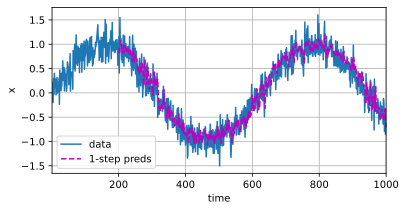

In [30]:
onestep_preds=net(features)
d2l.plot([time,time[200:]],
     [x.detach().numpy(),onestep_preds[196:].detach().numpy()],'time',
         'x',legend=['data','1-step preds'],xlim=[1,1000],
         figsize=(6,3))


In [33]:
multistep_preds=torch.zeros(T)
multistep_preds[:n_train+tau]=x[:n_train+tau]
for i in range(n_train+tau,T):
    multistep_preds[i]=net(
        multistep_preds[i-tau:i].reshape((1,-1)))

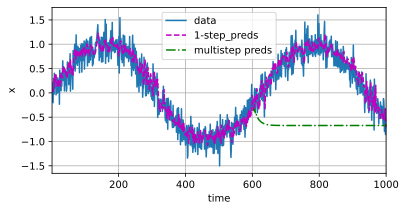

In [34]:
d2l.plot([time,time[tau:],time[n_train+tau:]],
         [x.detach().numpy(),onestep_preds.detach().numpy(),
          multistep_preds[n_train+tau:].detach().numpy()],'time',
         'x',legend=['data','1-step_preds','multistep preds'],
         xlim=[1,1000],figsize=(6,3))